# Intro
Modern analytics have reshaped the way teams make decisions in the NFL. Coaches seeking to maintain a competitive edge can no longer rely solely on conventional football wisdom when making critical fourth-down decisions. Instead, they must weigh the probability of a kicker successfully converting a field goal against the likelihood of their offense converting on fourth down, the field position value of a punt, and the expected win probability associated with each option. As a result, NFL strategy has increasingly come to resemble a game of chess, where marginal advantages can meaningfully influence outcomes. To make optimal decisions, coaches must understand the factors that drive success in field goal attempts.

Field goal performance in the NFL is influenced by a range of contextual factors, including stadium design, environmental conditions, and league rules. Differences in altitude, wind exposure, playing surface, and ball preparation may all affect a kicker’s ability to convert long-distance attempts. This analysis investigates whether these factors produce statistically significant differences in field goal outcomes. Using NFL play-by-play data from the past ten seasons (2016–2025), this paper determines what factors can have a statistically impact on field goal results. This is done by two methods:  
* Hypothesis testing to determine whether specific conditions affect the average distance of successful field goals.
* Regression analysis to predict the probability of a field goal conversion based on multiple factors simultaneously.

All statitical tests are  conducted at a significance level of  $\alpha$ = 0.05.

## Hypothesis Testing Overview
Each comparison is evaluated using a formal hypothesis test between two sample populations. For each test:
* The null hypothesis ($H_0$) assumes no meaningful difference between groups.
* The alternative hypothesis ($H_a$) represents the presence of an effect (directional or two-sided).

The p-value represents the probability of observing the given data assuming the null hypothesis is true. If the p-value is less than the chosen significance level, $\alpha$, the null hypothesis is considered unlikely enough that we reject it and conclude the alternative.

## Regression Analysis Overview
Regression analysis evaluates the relationship between several predictors and an outcome variable simultaneously. The model estimates how changes in each predictor are associated with changes in the predicted outcome while holding other variables constant. In this analysis, the outcome variable is whether a field goal attempt is successful. The model therefore produces a predicted probability that a field goal is made, allowing us to estimate how different factors influence the likelihood of conversion.

In [1]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import matplotlib.pyplot as plt
from scipy import stats
import math
from statsmodels.stats.proportion import proportions_ztest
import os
alpha = 0.05
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
%%capture
# Import nfl play by play data for the last 10 years. If not available download it, otherwise pull the data from the pkl file.
file_name ='pbp_data.pkl'
if not os.path.isfile(file_name):
    df = nfl.import_pbp_data(years = [2025- i for i in range(10)], downcast = True)
    df.to_pickle(file_name)
else:
    df = pd.read_pickle(file_name)

In [6]:
stadium_df = pd.read_csv('nfl_stadiums.csv', encoding = 'latin1')
rename_dict = {
    'GEHA Field at Arrowhead Stadium':'Arrowhead Stadium',
    "Levi's® Stadium":"Levi's Stadium",
    'Mercedes-Benz Stadium': 'Mercedes Benz Stadium',
    'Cleveland Browns Stadium':'Huntington Bank Field',
    'Commanders Field':'Northwest Stadium'
}
df = df.replace(rename_dict)
df = df.rename(columns = {'roof':'roof_status'})

In [7]:
# Add a season column
df['season'] = [id[:4] for id in df['game_id']]
df['season'] = df['season'].astype(int)


In [8]:
# Limit the df to only field goals
df_fg = df.loc[(df['play_type'] == 'field_goal') & (df['stadium'].isin(stadium_df['name']))].copy()

In [9]:
df_fg.loc[:,'fg_made'] = (df_fg['field_goal_result'] == 'made').astype(int)
df_fg.loc[:,'home'] = (df_fg['home_team'] == df_fg['posteam']).astype(int)
df_fg.loc[:, 'outdoors'] = df_fg['roof_status'] == 'outdoors'
df_fg['surface'] = df_fg['surface'].str.strip()

In [10]:
#cols = ['home_team','away_team', 'posteam', 'play_type', 'field_goal_result', 'kick_distance', 'yardline_100', 'stadium', 'stadium_id', 'game_stadium', 'roof', 'game_id']
cols = ['posteam', 'home', 'outdoors', 'roof_status', 'surface', 'fg_made', 'kick_distance', 'stadium', 'season']
df_fg = df_fg[cols]

# Part 1: Hypothesis Testing
The first analysis examines individual environmental factors by comparing two groups with hypothesis test to determine whether a condition affects the average distance of successful field goals.

In [11]:
def hypothesis_test(A, B, alpha, alt, A_label = 'A', B_label = 'B', value = 'Value', plot = True):
    """
    Conducts a hypothesis test of comparing the means of two groups. 
    
    Args:
        A: The first series
        B: The second series
        alpha: the significance level of the hypothesis test
        alt: The Alternative Hypothesis. Two sided, less, or greater
        A_label: The name of group A.
        B_label: The name of group B.
        value: The value being evaluated.
        Plot (boolean): If true, provide a box plot comparing the groups
        
    Returns:
        None. Results will be printed as output
    """
    
    assert alt in ['two-sided', 'less', 'greater']
    if len(A) == 0 or len(B)==0:
        print("One of the sets has no data")
        return
        
    alternative = {
        'two-sided': 'the two means are not equal',
        'less': f'the mean of  {A_label} is less than the mean of {B_label}',
        'greater': f'the mean of {A_label} is greater than the mean of {B_label}'
    }
    
    null = {
        'two-sided': 'the two means are equal',
        'less': f'the mean of {A_label} is greater than or equal to the mean of {B_label}',
        'greater': f'the mean of the {A_label} is less than or equal to the mean of {B_label}'
    }

    t_statistic, p_value = stats.ttest_ind(A, B, equal_var = True, alternative = alt)

    if plot:
        plt.figure(figsize=(5, 3))
        plt.boxplot([A, B], tick_labels=[A_label, B_label], showmeans=True)
        plt.ylabel(value)
        plt.show()
    
    display(pd.DataFrame({
        'mean':[A.mean(), B.mean()],
        'std': [A.std(), B.std()],
        'n': [len(A), len(B)],
        'SE': [A.std()/math.sqrt(len(A)), B.std()/math.sqrt(len(B))],
    }, index = [A_label, B_label]).round(2))


    
    if p_value < alpha:
        print(f"The p-value of {p_value:.3f} is less than the alpha of {alpha:0.2f}.\nWe can reject the null hypothesis and conclude {alternative[alt]}.")
    else:
        print(f"The p-value of {p_value:.3f} is greater than the alpha of {alpha:0.2f}.\nWe fail to reject the null hypothesis that {null[alt]}. ")

## Kicking in Denver
Due to the high altitude and subsequently thin air, Denver's stadium (aptly nick-named "Mile Hile") is believed to have an advantage for longer kicks and passes. This belief is supported by historical outliers, such as Matt Prater's 64-yard field goal in Denver in 2013, which was an NFL record that stood until 2021. It is a natural starting point when considering testing the impact of different environments. 

### Hypothesis: Are kicks made in Denver longer on average than all other stadiums?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{Denver}} \le \mu_{\text{Others}} \\
H_A &: \; \mu_{\text{Denver}} > \mu_{\text{Others}}
\end{aligned}
$$

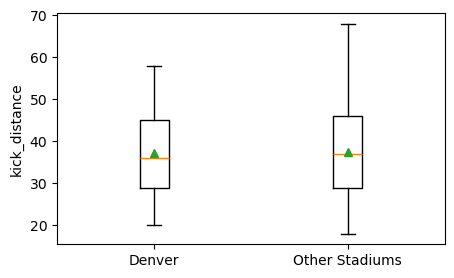

,mean,std,n,SE
Denver,37.119999,10.17,299,0.59
Other Stadiums,37.520000,10.12,8335,0.11


The p-value of 0.748 is greater than the alpha of 0.05.
We fail to reject the null hypothesis that the mean of the Denver is less than or equal to the mean of Other Stadiums. 


In [12]:
var = 'kick_distance'
atDenver = df_fg[(df_fg['stadium'] == 'Empower Field at Mile High') & (df_fg['fg_made'] == 1)][var]
away = df_fg[(df_fg['stadium'] != 'Empower Field at Mile High')  & (df_fg['fg_made'] == 1)][var]
hypothesis_test(atDenver, away, alpha, 'greater', A_label = 'Denver', B_label = 'Other Stadiums', value = var)

Despite Denver’s high altitude and reputation for long kicks, the results do not support a statistically significant difference. The average made field goal distance in Denver (37.12 yards) is nearly identical to the league-wide average (37.45 yards), with similar variability.

The null hypothesis cannot be rejected (p = 0.748), indicating that Denver does not provide a measurable advantage when compared to all other stadiums.
## Kicking in all other stadiums
This raises a broader question: do any stadiums provide a measurable advantage? To answer this, hypothesis tests are repeated for each NFL stadium, comparing that stadium’s average made field goal distance to the rest of the league. Because multiple stadium-level tests are conducted, results should be interpreted cautiously due to the increased risk of Type I error.
### Hypothesis: Are kicks made in a given stadium longer on average than all other stadiums?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{Stadium i}} \le \mu_{\text{Others}} \\
H_A &: \; \mu_{\text{Stadium i}} > \mu_{\text{Others}}
\end{aligned}
$$

In [13]:
result_ind = pd.DataFrame()
n = 30
for A in df_fg['stadium'].unique():
    sampleA = df_fg[(df_fg['stadium'] == A) & (df_fg['fg_made'] == 1)]['kick_distance']
    sampleB = df_fg[~(df_fg['stadium'] == A) & (df_fg['fg_made'] == 1)]['kick_distance']
    t_statistic, p_value = stats.ttest_ind(sampleA, sampleB, equal_var=True, alternative = 'greater')
    result_ind.loc[A, 'Environment'] = df_fg[(df_fg['stadium'] == A) & (df_fg['fg_made'] == 1)]['outdoors'].mode().replace({False:'Indoors', True:'Outdoors'})[0]
    result_ind.loc[A, 'mean'] = sampleA.mean()
    result_ind.loc[A, 'stdev'] = sampleA.std()
    result_ind.loc[A,'p_value'] = p_value
    result_ind.loc[A, 'Hypothesis test result'] = 'Reject H0' if p_value < alpha else 'Fail to reject H0'
result_ind.sort_values(by = 'mean', ascending = False).round(4)


,Environment,mean,stdev,p_value,Hypothesis test result
Mercedes Benz Stadium,Indoors,39.543900,10.2702,0.0002,Reject H0
Allegiant Stadium,Indoors,38.814999,11.1351,0.0322,Reject H0
AT&T Stadium,Indoors,38.628300,10.7226,0.0246,Reject H0
Acrisure Stadium,Outdoors,38.604801,9.8921,0.0299,Reject H0
State Farm Stadium,Indoors,38.512199,10.6103,0.0436,Reject H0
Ford Field,Indoors,38.505798,10.2918,0.0528,Fail to reject H0
NRG Stadium,Indoors,38.309399,10.0524,0.0787,Fail to reject H0
U.S. Bank Stadium,Indoors,38.235298,10.6705,0.1001,Fail to reject H0
Caesars Superdome,Indoors,38.033699,10.0377,0.1809,Fail to reject H0
Huntington Bank Field,Outdoors,37.918301,9.7781,0.2768,Fail to reject H0


When evaluating each stadium individually against the rest of the league, six stadiums show a statistically significant increase in mean field goal distance. Notably, five of them are indoor stadiums. While some outdoor stadiums are higher on the list, indoor stadiums have overall higher average field goal distance than outdoor stadiums. This pattern suggests that environmental control and the absence of any wind or weather impact has a stronger effect on kick distance than altitude alone. For stadiums with retractable roofs, no statistically significant differences are observed between games played with the roof open versus closed, result, retractable-roof stadiums are treated as indoor environments for subsequent analysis.
### Indoor vs Outdoor Stadiums
#### Hypothesis: Are kicks made indoors longer on average than kicks made outdoors?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{indoors}} \le \mu_{\text{outdoors}} \\
H_A &: \; \mu_{\text{indoors}} > \mu_{\text{outdoors}}
\end{aligned}
$$

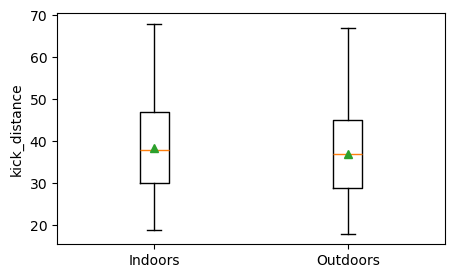

,mean,std,n,SE
Indoors,38.389999,10.41,2892,0.19
Outdoors,37.060001,9.94,5742,0.13


The p-value of 0.000 is less than the alpha of 0.05.
We can reject the null hypothesis and conclude the mean of Indoors is greater than the mean of Outdoors.


In [14]:
var = 'kick_distance'
indoors = df_fg[(df_fg['outdoors'] == False) & (df_fg['fg_made'] == 1)][var]
outdoors = df_fg[(df_fg['outdoors'] == True) & (df_fg['fg_made']==1)][var]
hypothesis_test(indoors, outdoors, alpha, 'greater', A_label = 'Indoors', B_label = 'Outdoors', value = var)

Indoor stadiums show a clear and statistically significant advantage. The average made field goal indoors is approximately 1.3 yards longer than outdoors (p < 0.001). This result provides one of the strongest signals in the analysis and suggests that controlled environments meaningfully improve long-distance kicking outcomes.
## Kicking in Denver compared to other outdoor fields
Let's go back to the initial theory about kicking in the high altitude in Denver. If the thin air has a statistical impact, it would be over other outdoor stadiums.

### Hypothesis: Are kicks made in Denver longer on average than kicks made in other stadiums outdoors?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{denver}} \le \mu_{\text{outdoors}} \\
H_A &: \; \mu_{\text{denver}} > \mu_{\text{outdoors}}
\end{aligned}
$$

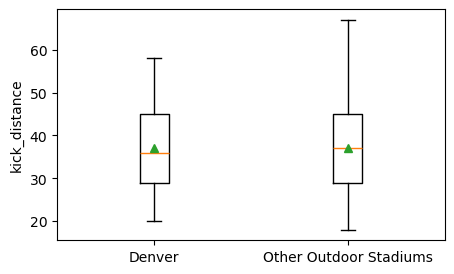

,mean,std,n,SE
Denver,37.119999,10.17,299,0.59
Other Outdoor Stadiums,37.060001,9.92,5443,0.13


The p-value of 0.455 is greater than the alpha of 0.05.
We fail to reject the null hypothesis that the mean of the Denver is less than or equal to the mean of Other Outdoor Stadiums. 


In [15]:
var = 'kick_distance'
denver = df_fg[(df_fg['stadium'] == 'Empower Field at Mile High') & (df_fg['fg_made'] == 1)][var]
others_outdoors = df_fg[(df_fg['stadium'] != 'Empower Field at Mile High') & (df_fg['outdoors']) & (df_fg['fg_made'] == 1)][var]
hypothesis_test(denver, others_outdoors, alpha, 'greater', A_label = 'Denver', B_label = 'Other Outdoor Stadiums', value = var)

Even when compared only to other outdoor stadiums, Denver does not show a meaningful impact on outcomes. The mean difference is negligible (0.06 yards), and the null hypothesis cannot be rejected (p = 0.455). This indicates that Denver’s altitude does not provide a statistically meaningful advantage relative to other outdoor venues.

## Kicking on different surfaces
Different stadiums have a different surfaces, including natural grass or a variety of types of artifical turf. The surface may have an impact on on the snap, hold, or plant at a field goal attempt. It is worth determining if grass or artificial turf has any impact on field goals.

### Hypothesis: Are kicks made in on grass longer on average than kicks made on turf?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{grass}} \ne \mu_{\text{turf}} \\
H_A &: \; \mu_{\text{grass}} = \mu_{\text{turf}}
\end{aligned}
$$

In [ ]:
var = "kick_distance"
grass = df_fg[(df_fg['surface'] == 'grass') & (df_fg['fg_made'] == 1)][var]
turf = df_fg[(df_fg['surface'] != 'grass') & (df_fg['fg_made'] == 1)][var]
hypothesis_test(grass, turf, alpha, 'two-sided', A_label = 'Grass', B_label = 'Turf', value = var)

Turf has a slightly higher mean kick distance (0.4 yards) compared to grass, but it narrowly misses statistical significance. 

### Impact of 2025 K-Ball rules change
In 2025, the NFL made a key change in the rules regarding field goals. Instead of giving teams access to the balls used for kicking plays (K-balls) immediately before the game, teams are given a set at the start of the season. This means teams can break those balls in over the course of weeks instead of minutes, and as a result, there has been an observed increase in field goal distances this year. Notably, Jaguars kicker Cam Little converted  an NFL record 68-yard field goal. It is worth investigating the statistical impact of kicks in 2025 vs prior years.

#### Hypothesis: Are kicks made in 2025 longer on average than kicks made before 2025?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{2025}} \le \mu_{\text{before 2025}} \\
H_A &: \; \mu_{\text{2025}} > \mu_{\text{before 2025}}
\end{aligned}
$$

In [ ]:
var = "kick_distance"
kicks_2025 = df_fg[(df_fg['season'] == 2025) & (df_fg['fg_made'] == 1)][var]
pre_2025 = df_fg[(df_fg['season'] != 2025) & (df_fg['fg_made'] == 1)][var]
hypothesis_test(kicks_2025, pre_2025, alpha, 'greater', A_label = '2025', B_label = '2016-2024', value = var)

Fairly conclusively, we can see an increase in kick distance in 2025. However, this could be due to increasing kicker skill over the years. We can narrow the comparison to the most recent year before the K-ball rules change for a more direct comparison. 
### Hypothesis: Are kicks made in a 2025 longer on average than kicks made in 2024?
$$
\begin{aligned}
H_0 &: \; \mu_{\text{2025}} \le \mu_{\text{2024}} \\
H_A &: \; \mu_{\text{2025}} > \mu_{\text{2024}}
\end{aligned}
$$

In [ ]:
var = "kick_distance"
kicks_2025 = df_fg[(df_fg['season'] == 2025) & (df_fg['fg_made'] == 1)][var]
kicks_2024 = df_fg[(df_fg['season'] == 2024) & (df_fg['fg_made'] == 1)][var]
hypothesis_test(kicks_2025, kicks_2024, alpha, 'greater', A_label = '2025', B_label = '2024', value = var)

Field goal distances in 2025 are significantly higher than the 2016–2024 average. However, when compared directly to 2024, the increase is smaller and narrowly misses statistical significance (p = 0.086). We can look at the year-over-year trends to see if there is a pattern.

In [ ]:
df_fg[df_fg['fg_made'] == 1].boxplot(column = 'kick_distance', by = 'season')
plt.show()
df_fg[df_fg['fg_made'] == 1].groupby('season').agg({'kick_distance':['mean','std']}).T.round(2)

While there has been a longer-term upward trend in kicking, 2025 still represents a peak in average field goal distance compared to prior years, suggesting that the new rules have some impact on field goal distance. 

# Part II Regression Analysis

Hypothesis testing only evaluates one variable at a time. When multiple variables influence an outcome simultaneously, this approach can produce unclear or misleading results. For example, in the earlier hypothesis testing analysis it was difficult to separate year-over-year improvements in kicking ability from the potential impact of the K-ball rule change.To address this limitation, we estimate a regression model that evaluates the effect of multiple variables on field goal outcomes simultaneously.

The following independent variables are included in the regression:
* Season: A continuous variable representing year over year changes
* Kick distance (yards): A continuous variable representing the distance of the field goal attempt.
* Home: A binary variable indicating whether the kicker was playing at their home stadium (0 = away, 1 = home).
* Outdoor: A binary variable indicating if the game took place in an outdoor stadium (0 = indoor, 1 = outdoor).
* Kball Rule: A binary variable indicating if the new K-ball rules have been implemented (0 = not implemented, IE before 2025, 1 implemented, IE 2025)
* Stadium: A binary variable for each of the NFL’s 30 stadiums indicating where the kick occurred. The base case is AT&T Stadium, meaning coefficients for other stadiums are interpreted relative to AT&T Stadium.
* posteam: The team attempting the kick. The Arizona Cardinals serve as the base case, so coefficients represent differences relative to Arizona’s field goal conversion rate.

The dependent variable is a binary indicator of whether the field goal was made. The regression therefore estimates the probability that a given kick will be successful.

The most important metrics in the regression output are the coefficients and p-values. Because the dependent variable indicates whether a kick was successful, each coefficient represents the marginal effect of that variable on the probability that the kick is made, holding all other variables constant. The p-value will be an important metric of statistical significance. It is the p-value of a hypothesis test where the coefficient value is equal to 0. If the p-value is less than our $\alpha$ of 0.05, we can conclude that the impact of the coefficient is significant. 

$$
\begin{aligned}
H_0 &: \; \beta_{\text{i}} = 0\\
H_A &: \; \beta_{\text{i}} \ne 0
\end{aligned}
$$


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc


In [ ]:
df_fg.loc[:,  'kball_rule'] = df_fg['season']==2025

In [ ]:
df_x = pd.merge(df_fg[['season', 'kick_distance', 'home', 'outdoors', 'kball_rule']], pd.get_dummies(df_fg[['stadium', 'posteam']]), right_index = True, left_index = True)
df_x = df_x.drop(['stadium_AT&T Stadium', 'posteam_ARI'],axis = 1).astype(float)
#df_x = df_fg[['season', 'kick_distance', 'outdoors', 'kball_rule']].copy()
#df_x = df_fg[['kick_distance', 'outdoors']].copy()
df_x = df_x.astype(float)
y  = df_fg['fg_made']
X = sm.add_constant(df_x)
model = sm.OLS(y, X).fit() 
print(model.summary())

fpr, tpr, thresholds = roc_curve(y, model.predict(X))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
results = pd.DataFrame({
    "coef": model.params,
    "pval": model.pvalues
}).round(3)

#### Statistically Significant Coefficients

In [ ]:
results[results['pval']<alpha]

## Regression Interpretation

### Model Accuracy

Model performance is evaluated using the ROC–AUC score, which measures the model’s ability to distinguish between successful and unsuccessful kicks. The regression yields an AUC score of 0.77, meaning that when comparing a randomly selected successful kick and unsuccessful kick, the model assigns a higher predicted probability to the successful kick 77% of the time. For reference, a random prediction would produce an AUC of 0.50, so this represents a meaningful improvement. While not approaching the accuracy of highly optimized predictive models, this level of performance is reasonable given the inherent noise and variability present in sports data.

Although $R^2$ is commonly used to evaluate regression models, it is not particularly informative for binary outcomes and therefore is not emphasized in this analysis.

### Output interpretation
The regression identifies several variables with statistically significant effects on field goal success.

The variable with the strongest statistical impact (p < 0.001) is kick distance. This aligns with expectations: longer kicks are more difficult to convert. The coefficient indicates that each additional yard reduces the probability of a successful kick by approximately 1.15 percentage points, holding all other variables constant. The next clearest signal came from indoors vs outdoors environments. The outdoors coefficient had the second strongest statistical impact (p = 0.008), kicks taken outdoors were 5.5% less likely to be converted than a kick taken indoors, all else being equal.

There is also evidence of year-over-year improvement in kicking performance. The season variable is statistically significant (p = 0.044), suggesting that field goal success rates have gradually improved over time. The coefficient implies that, all else equal, the probability of converting a field goal increased by roughly 0.3 percentage points per season.

Several variables were not statistically significant, which is also informative. Most notably, the K-ball rule change does not have a statistically significant effect (p = 0.186). This suggests that any improvement in field goal outcomes observed after the rule change is consistent with the existing trend of gradual improvement rather than a direct effect of the rule itself. Similarly, the model does not find evidence of a general home-field advantage for kickers, as the home variable is not statistically significant.

#### Stadium Effects

The regression also provides insight into stadium-specific effects. After controlling for indoor vs. outdoor conditions, most stadiums do not have a statistically significant effect on kicking outcomes relative to AT&T Stadium. However, two stadiums show a statistically significant negative impact on field goal success:
* Huntington Bank Field (Cleveland)
* Gillette Stadium (New England)

These results are consistent with expectations. Cleveland frequently experiences strong winds from Lake Erie, while New England is known for cold temperatures and difficult late-season weather conditions.

Two stadiums show a statistically significant positive effect on field goal success:
* EverBank Stadium (Jacksonville)
* Nissan Stadium (Tennessee)

These locations tend to have milder weather conditions that may be more favorable for kicking.

#### Team Effects 
The regression identifies statistically significant effects for three teams:

* Baltimore Ravens
* Pittsburgh Steelers
* Kansas City Chiefs

Field goal attempts by these teams were 10.3%, 8.1%, and 6.2% more likely, respectively, to be successful than attempts by the Arizona Cardinals, holding all other variables constant.

Several factors may contribute to this difference. First, these organizations exhibited exceptional coaching stability during the period studied. All three teams retained the same head coach throughout the timeframe. In addition, the Chiefs and Steelers each had a single special teams coordinator, while the Ravens had only two. This level of stability is unusual in the NFL and likely reflects strong coaching quality, likely providing consistent special teams development as well as excellent in-game decision making.

Second, these teams employed elite kickers during the period analyzed:
* The Steelers had Chris Boswell for the entire period.
* The Chiefs had Harrison Butker for all seasons except 2016.
* The Ravens had Justin Tucker for all seasons except 2025.

All three kickers have been widely regarded as among the best in the league, providing consistently reliable performance over time.

# Conclusion
Through hypothesis testing and regression analysis, this study identifies several factors that have a measurable impact on field goal success in the NFL. Aside from kick distance, the clearest signal is the difference between indoor and outdoor environments. Field goals attempted outdoors are approximately 5.5% less likely to be successful than comparable kicks attempted indoors. In addition, four stadiums show statistically significant effects on kicking outcomes. The challenging weather conditions at Gillette Stadium in New England and Huntington Bank Field in Cleveland reduce field goal success rates by 4.5% and 5.8%, respectively, while the more favorable conditions at EverBank Stadium in Jacksonville and Nissan Stadium in Nashville increase success rates by 5.4% and 4.6%.

Equally important, the analysis suggests that several commonly held beliefs about field goal performance are not supported by the data. Denver’s high-altitude environment does not produce a statistically significant advantage in either hypothesis testing or regression analysis. Similarly, the rule change giving teams earlier access to K-balls does not appear to have increased field goal success beyond the existing year-over-year improvement trend.

These findings can provide useful insights for coaches making strategic decisions in the NFL. Understanding the environmental and contextual factors that influence kicking success can help teams better evaluate fourth-down decisions and optimize game strategy. Incorporating these probabilities into can provide valuable context when determining how aggressively to pursue a field goal attempt or how to best prepare for games in stadiums where kicking conditions are historically more challenging.

In [ ]:
%%capture
!jupyter nbconvert "NFL_FieldGoalAnalysis.ipynb" \
    --to html \
    --TemplateExporter.exclude_input=True \
    --output "index.html"